In [1]:
#------------------- Change working directory to project root -------------------#
from pathlib import Path, os

cur = Path().resolve()
while not (cur / "src").is_dir():
    if cur == cur.parent: raise RuntimeError("No 'src' dir")
    cur = cur.parent

os.chdir(cur)
print(f"[INFO] Changed working directory to project root: {cur}")

[INFO] Changed working directory to project root: /home/fernando/Documents/LoRaPriv


In [2]:
# -------------------------------------- External Dependencies -----------------------------------
import numpy as np
from typing import Union
from datetime import datetime
from typing import Callable
import matplotlib.pyplot as plt
import random
from collections import defaultdict
import time
# ----------------------------------------- Local Imports ----------------------------------------
from src.mod                   import LoRaModulator, plot_frame
from src.demod                 import LoRaDemodulator, plot_demodulation
from src.sync                  import DechirpBasedSynchronizer, CorrelationBasedSynchronizer, plot_synchronization
from src.core.vpn_utils        import VPNKeepAlive

import src.core.params as params
import src.core.sdr_utils as sdr_utils
import src.core.snr_utils as snr_utils
import src.core.perf_metrics_utils as perf_utils


In [ ]:
phy_params = params.LoRaPhyParams(
    spreading_factor=8,
    bandwidth= 500e3,
    samples_per_chip=2
)

frame_params = params.LoRaFrameParams(
    preamble_symbol_count=8,
    explicit_header=True
)

sync_params = params.LoRaSyncParams(
    sync_source=params.SyncSource.DECHIRPING,
    source_params=params.DechirpingSyncParams(
        max_sync_candidates=10,
        compensate_frequency_offset = True
    )
)

fold_mode = params.LoRaFoldMode.OPA
simd_backend = "cupy"

modulator = LoRaModulator(
    phy_params=phy_params,
    frame_params=frame_params,
    backend="numpy")


### El Problema: Desalineación de Fase Intra-Símbolo (0PA)

Un demodulador LoRa estándar asume que la fase de la señal es continua a lo largo de un mismo símbolo. Sin embargo, como demuestran Xu et al. (2022), esta suposición es incorrecta y es la causa fundamental de la pérdida de rendimiento en implementaciones SDR de código abierto.

El problema se origina en el mecanismo de modulación de LoRa. Un símbolo de datos (distinto de cero) se genera mediante un desplazamiento cíclico de un chirp base. Esto provoca que el chirp tenga dos segmentos:
1.  Uno que va desde la frecuencia de inicio $f_{start}$ hasta el borde del ancho de banda ($BW$).
2.  Un segundo que, tras un **salto instantáneo** de frecuencia a $0$ Hz, continúa hasta completar el tiempo del símbolo.

Es en este **salto de frecuencia intra-símbolo** donde se produce la vulnerabilidad. Debido a inestabilidades del hardware (o quizás también por efectos del canal), se introduce un **desfase aleatorio e impredecible ($\Delta\phi$)** entre los dos segmentos.

Al realizar la dechirping, los dos segmentos se convierten en tonos de la misma frecuencia, pero con fases distintas. Si se procesan juntos (sin alineación de fase o "0PA") en una suma coherente $^1$, sus energías se suman de forma **destructiva** en la FFT. El resultado es un pico de frecuencia distorsionado, atenuado o incluso dividido en dos, lo que provoca una pérdida de SNR y errores de demodulación, especialmente en condiciones de bajo SNR donde LoRa debería destacar.

$^1$ Una suma coherente se refiere a cualquier suma de señales complejas donde su fase también es tenida en cuenta y están alineadas. Resulta una suma incoherente si al ejecutar la operación las señales no estaban alineadas en fase, destruyéndose mutuamente u obteniendo un resultado no deseado.

### Simulación del Canal con Desalineación de Fase

Para verificar el impacto de la desalineación de fase y evaluar el rendimiento de los distintos demoduladores (OPA, CPA y FPA), simulamos este efecto sobre una señal LoRa ideal. El proceso emula la imperfección del hardware descrita anteriormente:

1.  **Cálculo del Punto de Discontinuidad:** Primero, se calcula la muestra exacta dentro del símbolo donde ocurre el salto de frecuencia ("wrap-around"). Para un símbolo de valor `S`, este punto corresponde al momento en que el chirp, que comenzó en una frecuencia proporcional a `S`, alcanza el borde del ancho de banda.

2.  **Generación de un Error de Fase:** Se genera un desfase, $\Delta\phi$, modelado como un fasor complejo $e^{j\Delta\phi}$. Este fasor representa el cambio de fase abrupto e impredecible que introduce el hardware.

3.  **Aplicación Selectiva:** El fasor se multiplica muestra por muestra **únicamente** por el segundo segmento del chirp; es decir, desde el punto de discontinuidad hasta el final del símbolo. El primer segmento permanece inalterado.

El resultado es una forma de onda que emula fielmente la señal que recibiría un demodulador en presencia de este tipo de imperfección física, permitiéndonos analizar su resiliencia de forma controlada.

In [4]:
symbol = 100
phase_misalignment_rad = 4

In [5]:

signal, viz_bundle = modulator.modulate([symbol], include_frame=False, debug_bundle=True)


discontinuity = ( phy_params.samples_per_chip * (phy_params.chips_per_symbol - symbol) ) + 1
print(discontinuity)

phasor= 1 * np.exp(1j*phase_misalignment_rad)

distorted_waveform = np.copy(signal)
distorted_waveform[discontinuity:] *= phasor

313


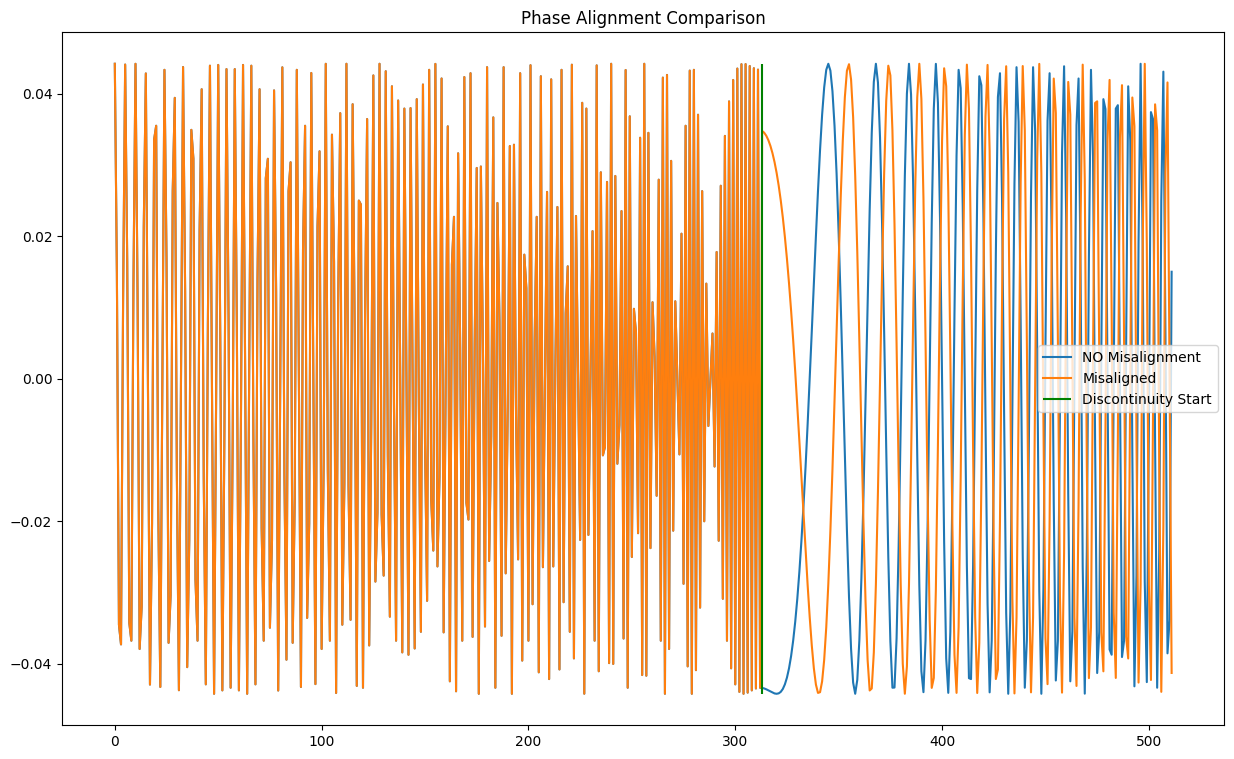

In [6]:
plt.figure(figsize=(15, 9))
plt.title("Phase Alignment Comparison")
plt.plot(np.real(signal), label= "NO Misalignment")
plt.plot(np.real(distorted_waveform), label ="Misaligned")
plt.vlines(discontinuity, np.min(np.real(distorted_waveform)), np.max(np.real(distorted_waveform)), "green", label = "Discontinuity Start")
plt.legend()
plt.show()

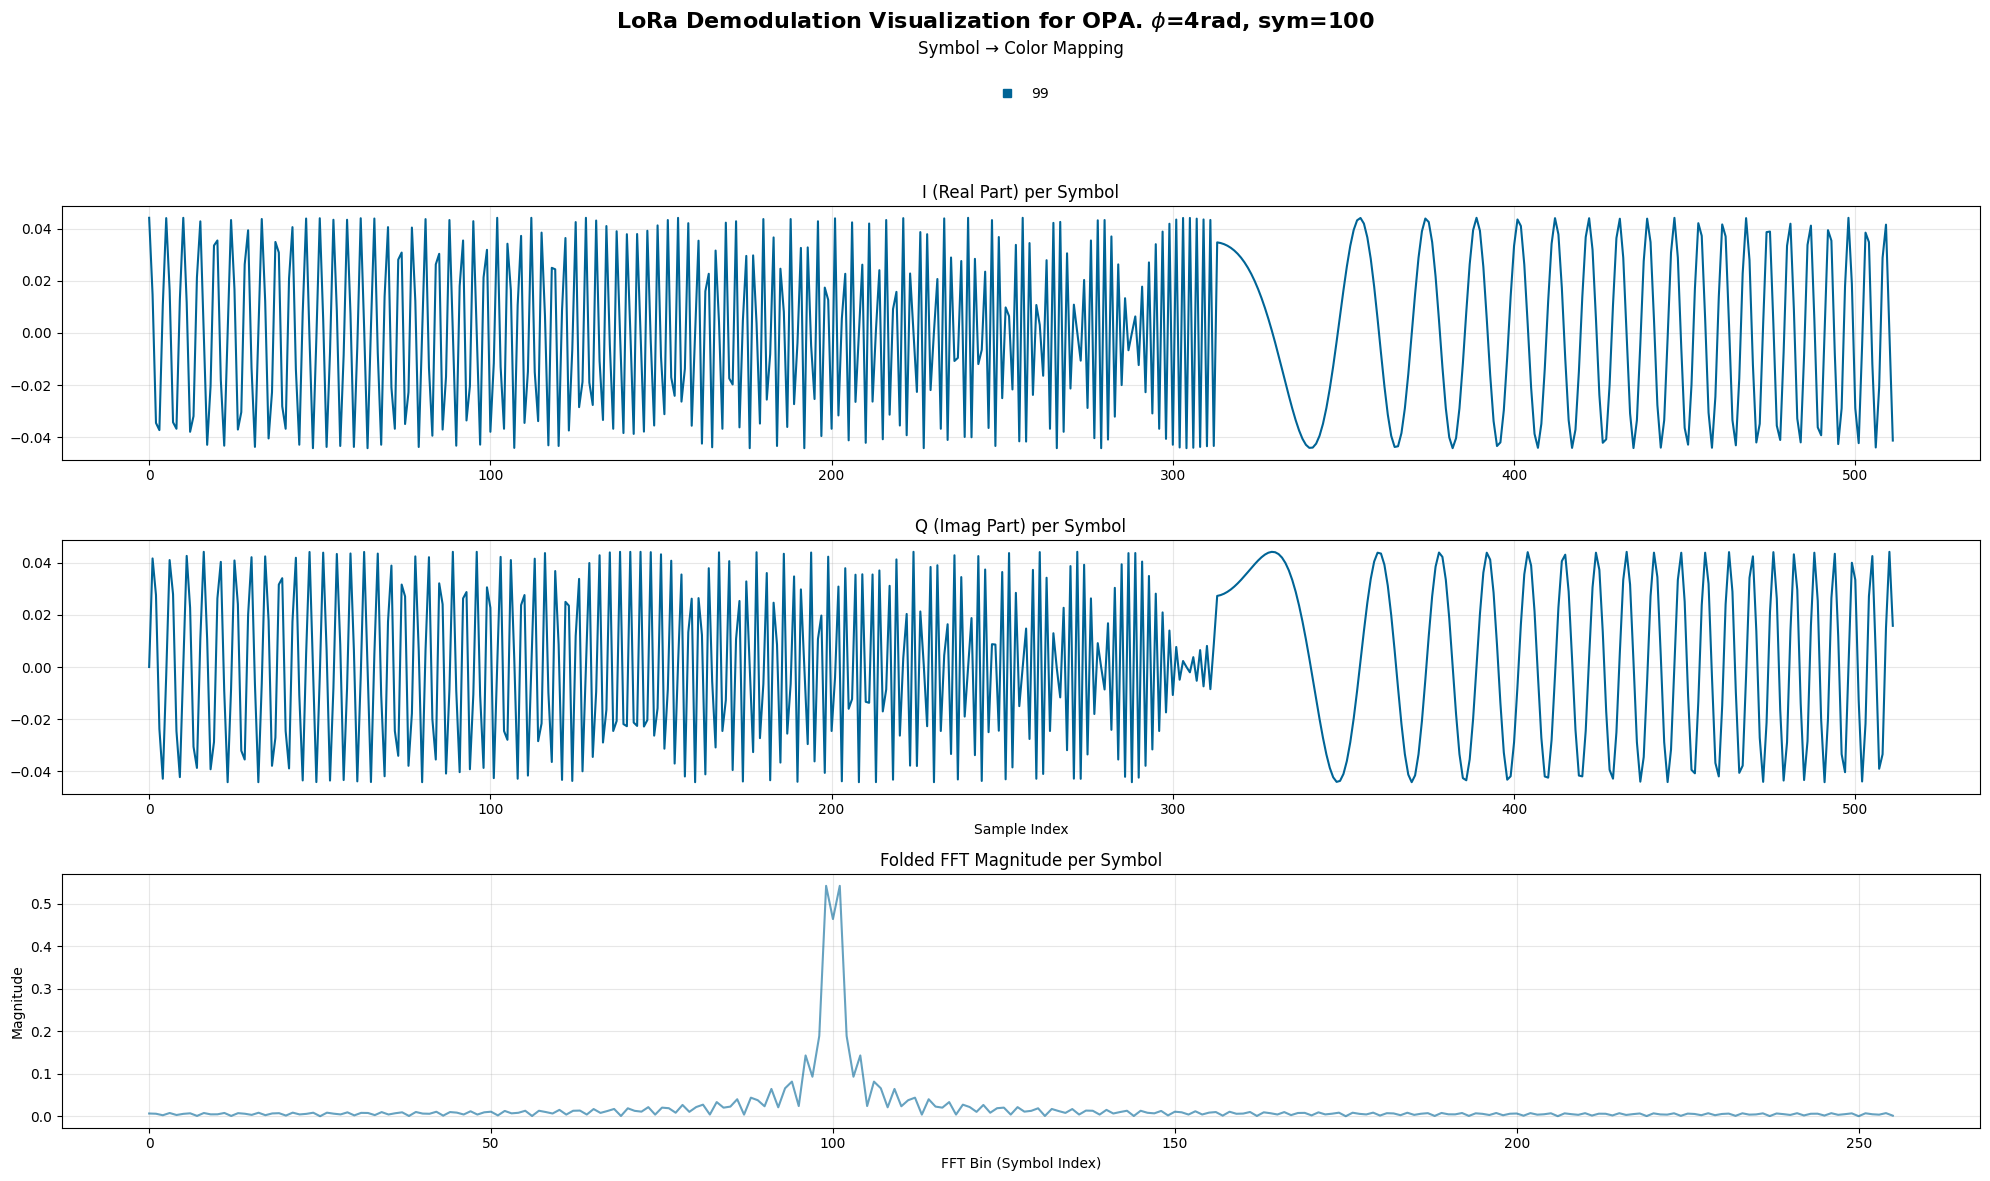

In [7]:
OPA_demod = LoRaDemodulator(
    phy_params=phy_params,
    backend=simd_backend,
    fold_mode= params.LoRaFoldMode.OPA)

OPA_rx_payload, OPA_viz_bundle = OPA_demod.demodulate(distorted_waveform, return_items=["symbols", "viz_bundle"])
plot_demodulation(OPA_viz_bundle, title=f"LoRa Demodulation Visualization for OPA. $\phi$={round(phase_misalignment_rad,2)}rad, sym={symbol}", dft_color="#006496")

### Solución 1: Coarse-grained Phase Alignment (CPA)

El método de **Alineación de Fase Gruesa (CPA)** es una solución computacionalmente eficiente que esquiva el problema del desfase en lugar de corregirlo. La estrategia se basa en trabajar con las **magnitudes** de la señal, que no se ven afectadas por la fase.

El proceso es el siguiente:
1.  **Oversampling:** Se muestrea la señal a una frecuencia superior a $2 \cdot BW$. Esto es crucial, ya que permite que, tras la dechirping, los dos segmentos del símbolo aparezcan como **dos picos distintos y separados** en el dominio de la frecuencia.
2.  **Suma de Amplitudes:** En lugar de sumar los valores complejos de los dos picos (lo que fallaría por el desfase), el CPA suma sus **valores absolutos (amplitudes)**.

Matemáticamente, si tras la FFT de la señal sobremuestreada y dechirpeada obtenemos dos picos complejos, $P_A$ y $P_B$, que representan los dos segmentos del chirp, su suma coherente ideal sería $P_{ideal} = P_A + P_B$. Sin embargo, debido al desfase desconocido $\Delta\phi$, la suma directa $P_A + P_B \cdot e^{j\Delta\phi}$ resulta en una interferencia destructiva.

El CPA evita este problema operando sobre las magnitudes. La altura del pico resultante se calcula como:

$|P_{CPA}| = |P_A| + |P_B|$

Dado que la amplitud de un pico es proporcional a la energía de su segmento de chirp correspondiente, esta suma de magnitudes concentra la energía total en un único valor, aproximándose a la altura del pico ideal.

**Ventajas:**
*   **Extremadamente Rápido:** Solo requiere operaciones de valor absoluto y suma, lo que lo hace ideal para hardware de bajo coste.
*   **Robusto:** Al no depender de la fase, es inmune a cualquier valor de $\Delta\phi$.

**Desventajas:**
*   **Subóptimo:** La suma de magnitudes también implica una suma incoherente del ruido subyacente a cada pico, lo que eleva el piso de ruido general. Además, este proceso ensancha el lóbulo principal del pico resultante, provocando una ligera pérdida de sensibilidad en comparación con FPA.

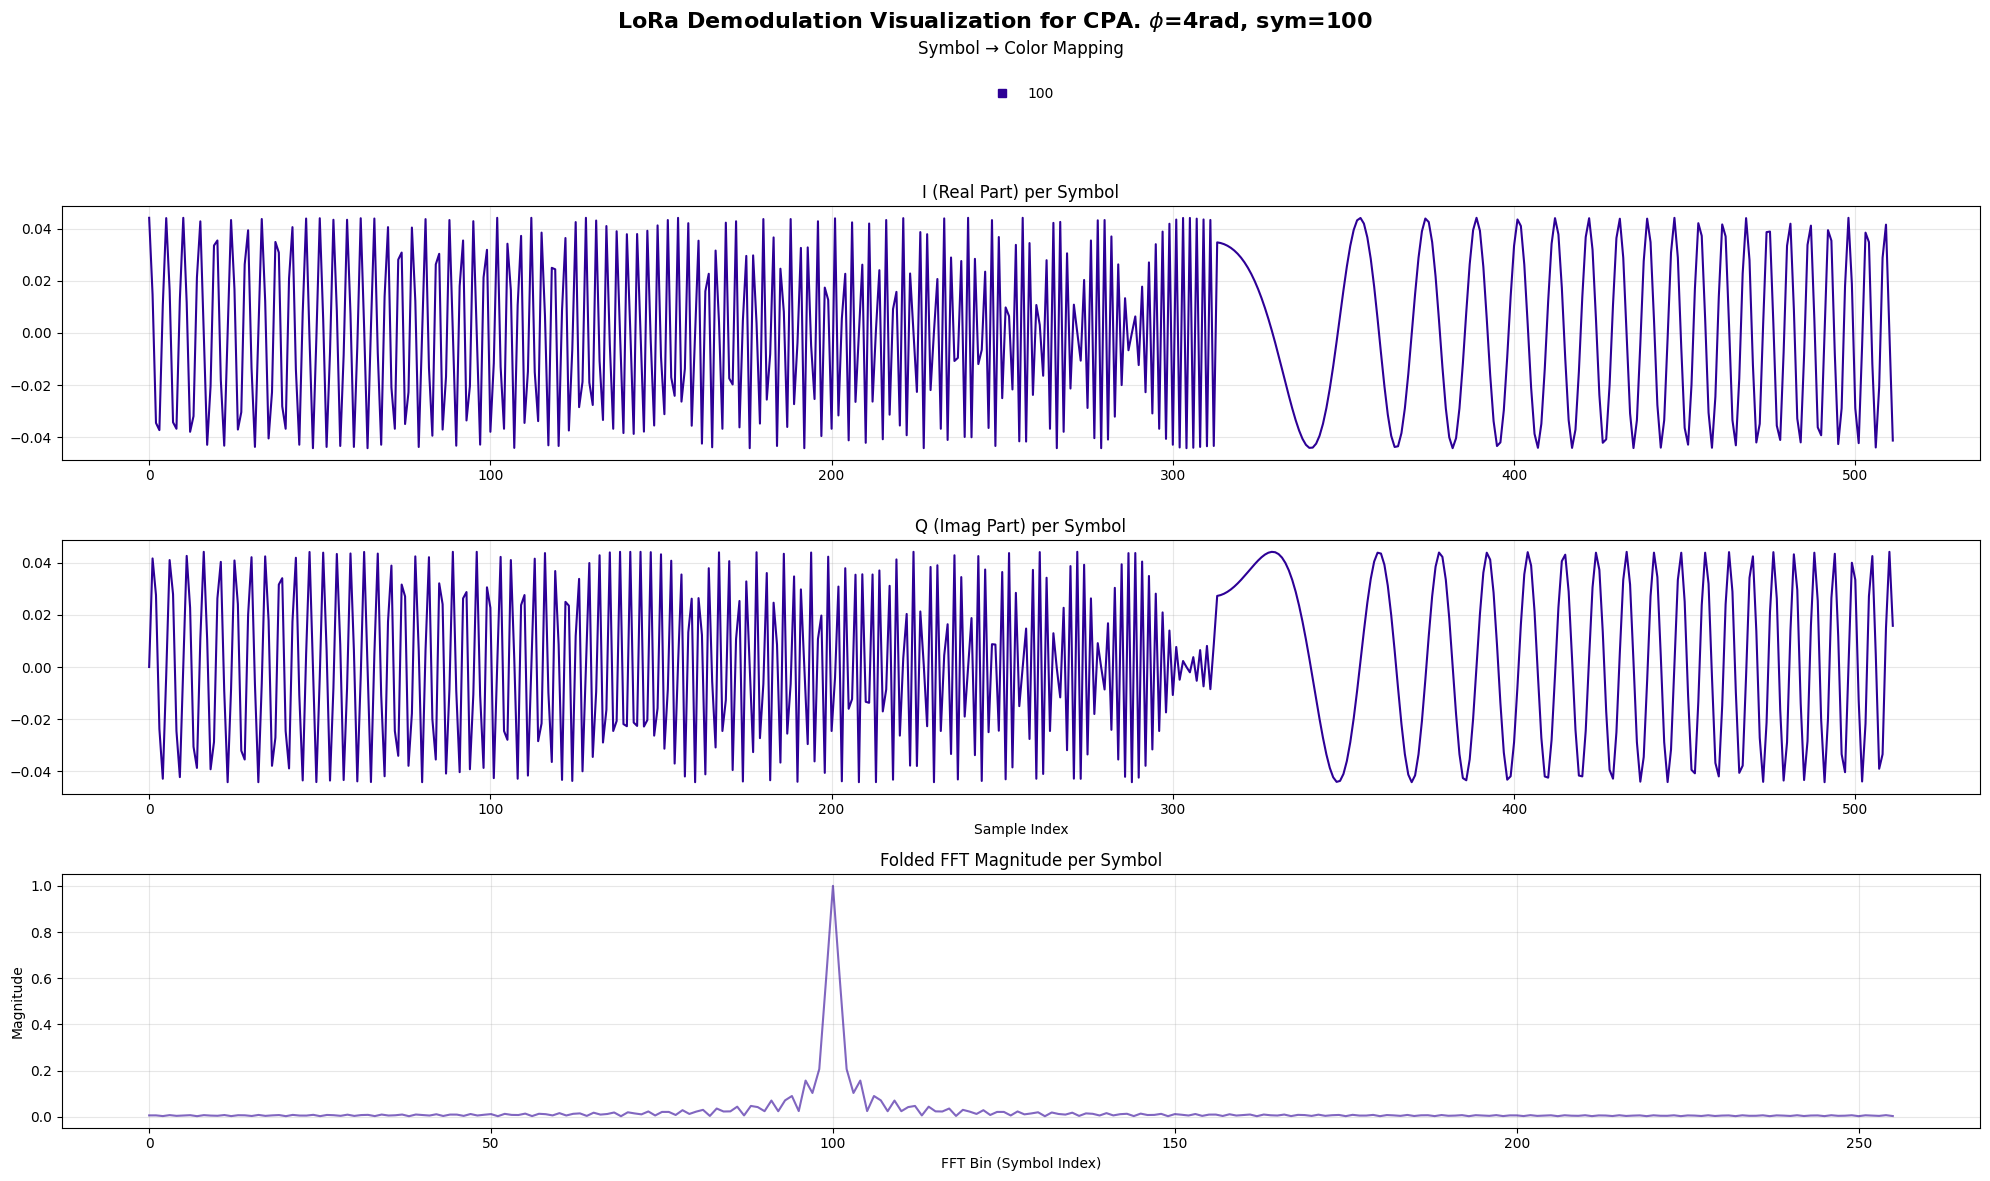

In [8]:
CPA_demod = LoRaDemodulator(
    phy_params=phy_params,
    backend=simd_backend,
    fold_mode= params.LoRaFoldMode.CPA)

CPA_rx_payload, CPA_viz_bundle = CPA_demod.demodulate(distorted_waveform, return_items=["symbols", "viz_bundle"])

plot_demodulation(CPA_viz_bundle, title=f"LoRa Demodulation Visualization for CPA. $\phi$={round(phase_misalignment_rad,2)}rad, sym={symbol}", dft_color="#2d0096")


### Solución 2: Fine-grained Phase Alignment (FPA)

El método de **Alineación de Fase Fina (FPA)** es una aproximación más sofisticada que busca activamente **corregir el desfase** para lograr una suma coherente y, por tanto, un rendimiento cercano al ideal.

El proceso es el siguiente:
1.  **Oversampling:** Al igual que en el CPA, se utiliza sobremuestreo para obtener los dos picos complejos ($P_A$ y $P_B$) de forma separada en la FFT.
2.  **Búsqueda y Compensación:** FPA trata la corrección del desfase como un problema de optimización. Realiza una búsqueda iterativa sobre un conjunto discreto de $k$ posibles valores de desfase para encontrar el ángulo de corrección $\Delta\hat{\phi}$ que maximice la energía de la suma coherente.
3.  **Selección del Máximo:** Para cada ángulo de prueba $\Delta\phi_i$, se rota el fasor de uno de los picos y se calcula la magnitud de la suma. El ángulo que produce la máxima magnitud es seleccionado como la mejor estimación del desfase.

Matemáticamente, el proceso se describe como:

$\Delta\hat{\phi} = \underset{\Delta\phi_i}{\arg\max} |P_A + P_B \cdot e^{-j\Delta\phi_i}|$

donde el conjunto de ángulos de prueba es $\Delta\phi_i = i \cdot \frac{2\pi}{k}$ para $i = 0, 1, \dots, k-1$. El *paper* sugiere un valor empírico de $k=16$ como un buen equilibrio entre rendimiento y coste computacional.

Una vez encontrado el desfase óptimo $\Delta\hat{\phi}$, el pico combinado final se calcula como $P_{FPA} = P_A + P_B \cdot e^{-j\Delta\hat{\phi}}$. El resultado es un único pico de energía concentrada, muy similar al caso ideal.

**Ventajas:**
*   **Rendimiento Casi Ideal:** Al lograr una suma coherente con corrección de fase, la sensibilidad del demodulador se aproxima al límite teórico de LoRa.

**Desventajas:**
*   **Computacionalmente Caro:** La búsqueda iterativa requiere $k$ multiplicaciones complejas y $k$ comparaciones de magnitud por cada símbolo, lo que aumenta notablemente la carga computacional.


--- Analysis for Symbol---
WINNING PHASE: 2.3562 rad
Comparison of all candidate phases:
  Phase (rad)  | Peak Magnitude
---------------------------------
  0.0000       | 0.5426 
  0.3927       | 0.6139 
  0.7854       | 0.7488 
  1.1781       | 0.8597 
  1.5708       | 0.9407 
  1.9635       | 0.9880 
  2.3562       | 0.9993 <-- WINNER
  2.7489       | 0.9743 
  3.1416       | 0.9138 
  3.5343       | 0.8209 
  3.9270       | 0.7001 
  4.3197       | 0.5582 
  4.7124       | 0.5601 
  5.1051       | 0.5898 
  5.4978       | 0.5968 
  5.8905       | 0.5809 


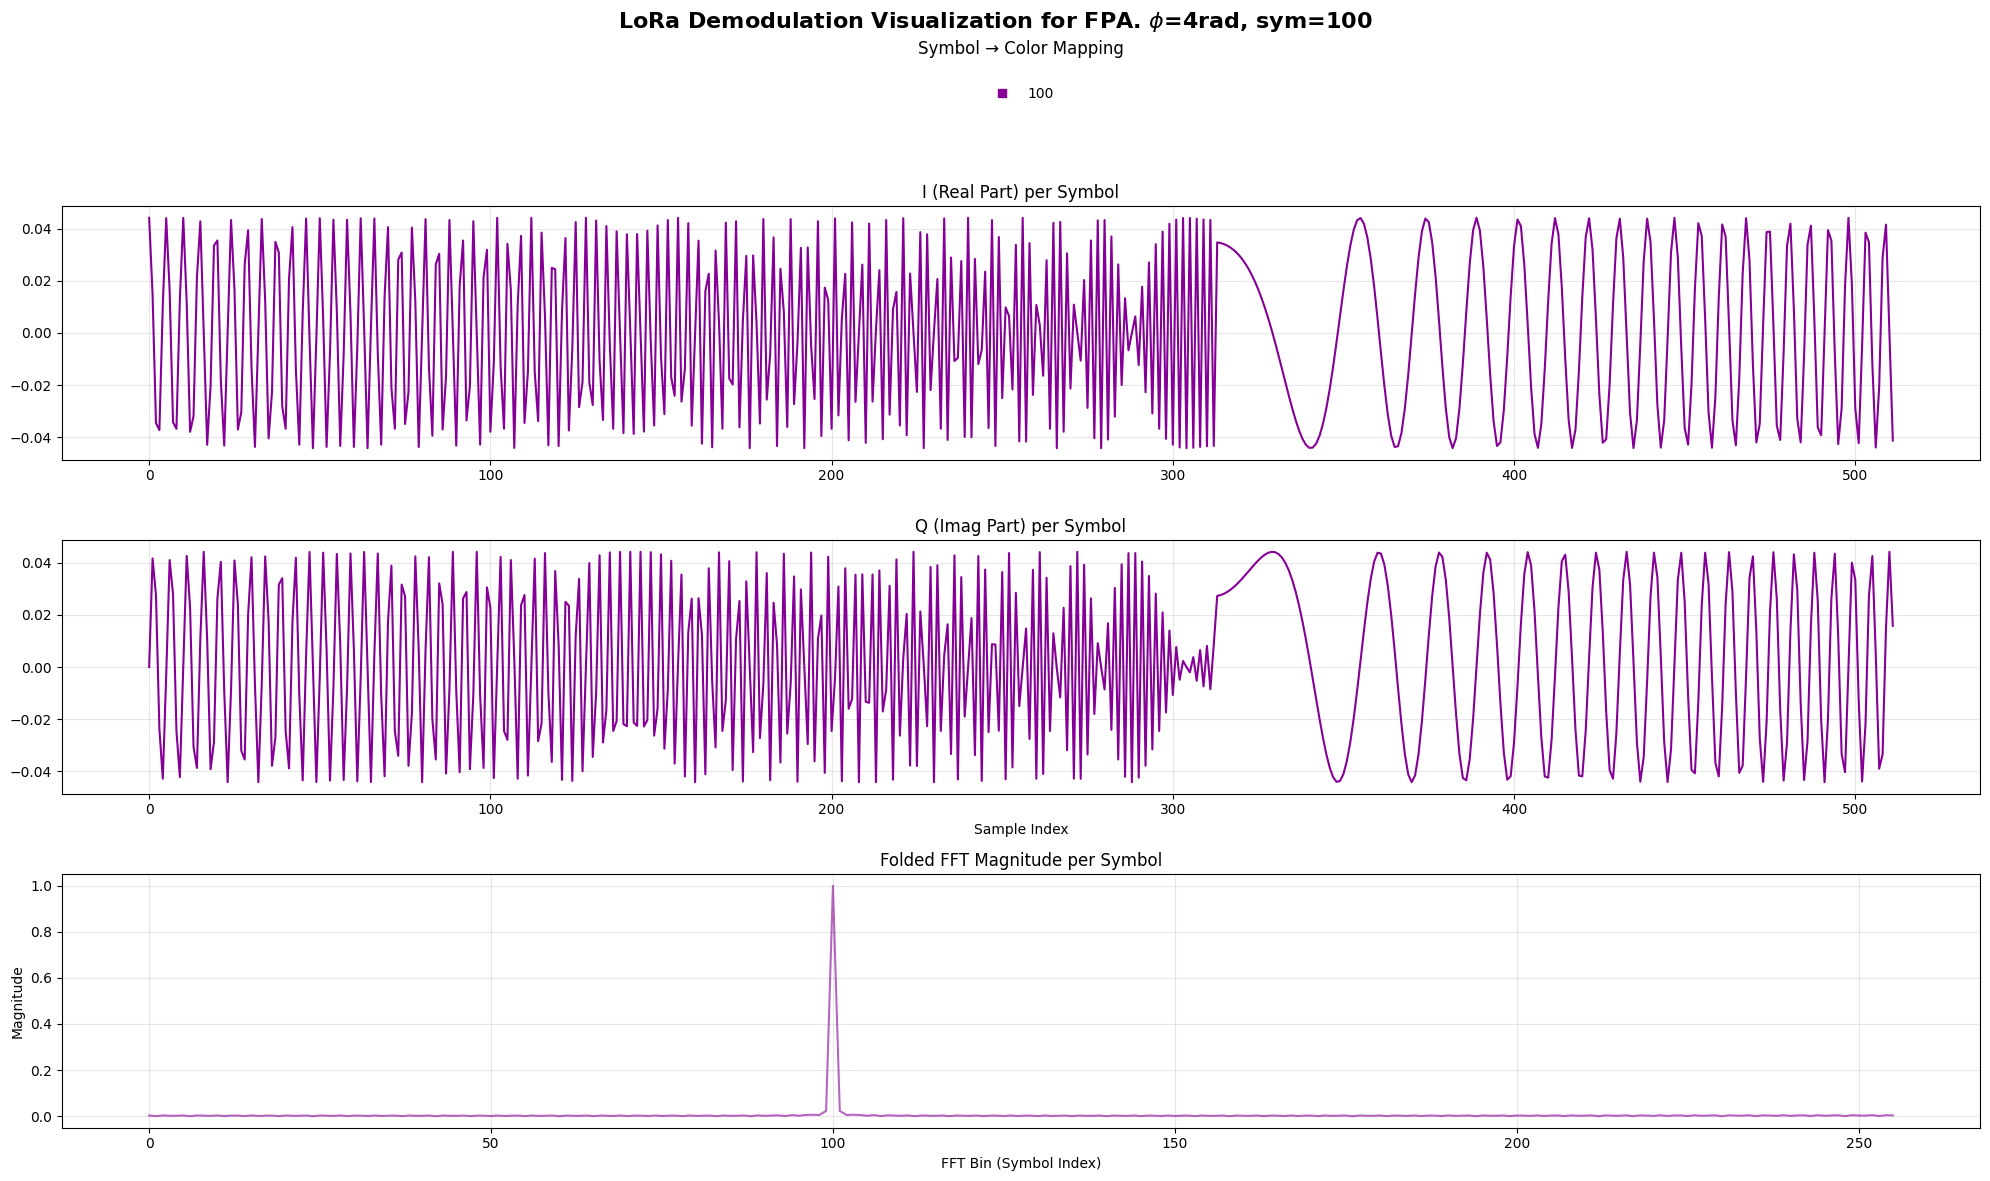

In [9]:
FPA_demod = LoRaDemodulator(
    phy_params=phy_params,
    backend=simd_backend,
    fold_mode= params.LoRaFoldMode.FPA,
    debug_fpa=True
    )

FPA_rx_payload, FPA_viz_bundle = FPA_demod.demodulate(distorted_waveform, return_items=["symbols", "viz_bundle"])

plot_demodulation(FPA_viz_bundle, title=f"LoRa Demodulation Visualization for FPA. $\phi$={round(phase_misalignment_rad,2)}rad, sym={symbol}", dft_color="#850096")